# Machine learning 

## Predicting student final grade using different machine learning algorithms  

For this analysis I will use the student data to predict their final grade using different machine learningß0 regression
You can download the Student Performance data here: https://archive.ics.uci.edu



Installing Necessary Packages and import Modules/Packages
You can use pip install *package* from the command prompt


In [1]:
import numpy as np
import pandas as pd
import pickle 
import matplotlib.pyplot as plt
from matplotlib import style
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
import seaborn as sns
import os
from sklearn.metrics import r2_score
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

Loading in Our Data
Once you've downloaded the data set and placed it into your main directory you can load it in using the pandas module.

In [2]:
data = pd.read_csv("data/student-mat.csv", sep=";")

In [3]:
print(data.shape)           # Number of rows and columns
print(data.columns.tolist())# All column names
print(data.dtypes)          # Data type of each column
data.head()                 # to see data frame, first 5 rows

(395, 33)
['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']
school          str
sex             str
age           int64
address         str
famsize         str
Pstatus         str
Medu          int64
Fedu          int64
Mjob            str
Fjob            str
reason          str
guardian        str
traveltime    int64
studytime     int64
failures      int64
schoolsup       str
famsup          str
paid            str
activities      str
nursery         str
higher          str
internet        str
romantic        str
famrel        int64
freetime      int64
goout         int64
Dalc          int64
Walc          int64
health        int64
absences      int64
G1            int64
G2            int64
G3            int64
dt

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


It is always best practise to do Exploratory Data Analysis (EDA) before fitting any machine learning model.

Below one can quickly do descriptive stat.
This gives
    Mean
    Standard deviation
    Minimum
    Maximum
    Quartiles

In [4]:
data[['G1','G2','G3']].describe()

,G1,G2,G3
count,395.000000,395.000000,395.000000
mean,10.908861,10.713924,10.415190
std,3.319195,3.761505,4.581443
min,3.000000,0.000000,0.000000
25%,8.000000,9.000000,8.000000
50%,11.000000,11.000000,11.000000
75%,13.000000,13.000000,14.000000
max,19.000000,19.000000,20.000000


Histograms. This shows the distribution of each grade.
    This tells; 
    Are grades centred around the pass mark?
    Is the distribution skewed?
    Are there many students scoring zero?

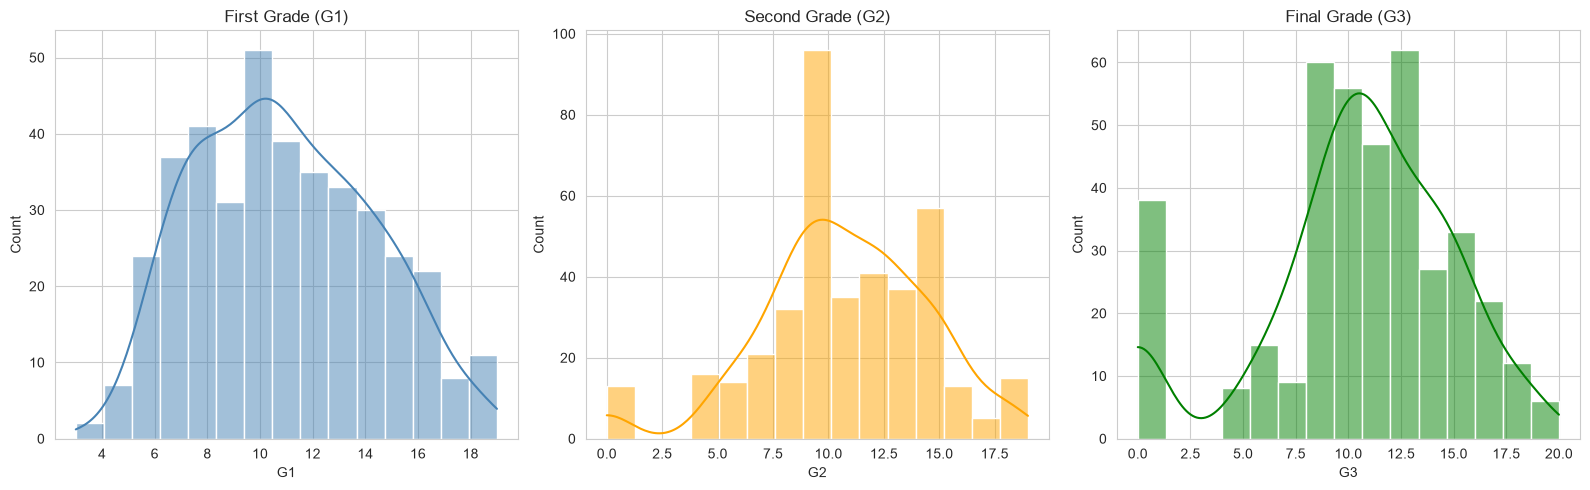

In [5]:
fig, ax = plt.subplots(1, 3, figsize=(16, 5))
sns.set_style("white")
sns.histplot(data["G1"], bins=15, kde=True, ax=ax[0], color="steelblue")
ax[0].set_title("First Grade (G1)")
sns.histplot(data["G2"], bins=15, kde=True, ax=ax[1], color="orange")
ax[1].set_title("Second Grade (G2)")
sns.histplot(data["G3"], bins=15, kde=True, ax=ax[2], color="green")
ax[2].set_title("Final Grade (G3)")
fig.tight_layout()
fig.savefig("figures/histograms.png", dpi=300, bbox_inches="tight")
plt.show()

Violin Plot
A violin plot combines a boxplot with the full data distribution.

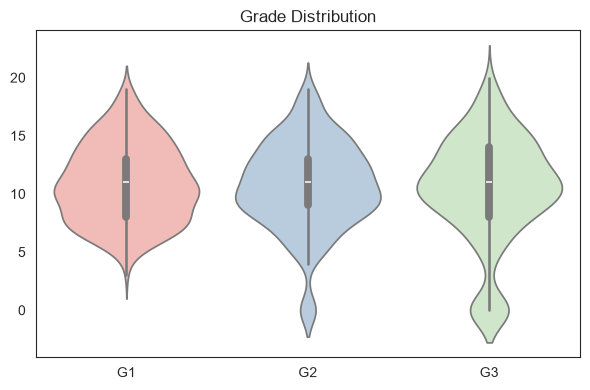

In [6]:
plt.figure(figsize=(6,4))
sns.set_style("white") # Remove gridlines
sns.violinplot(data=data[['G1','G2','G3']], palette="Pastel1")
plt.title("Grade Distribution")
plt.tight_layout()
plt.savefig("figures/Violin_PlotA.png", dpi=300)
plt.show()

Boxplots
    This shows;
    Median
    Spread
    Outliers

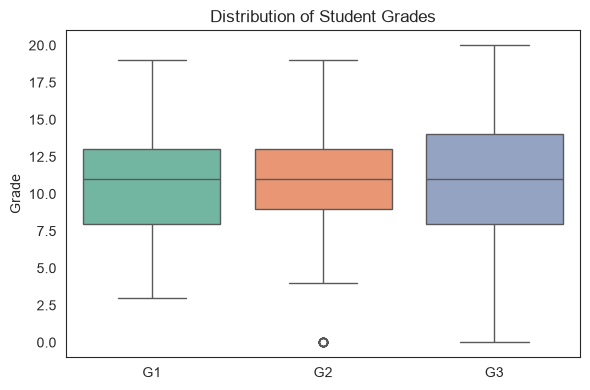

In [7]:
plt.figure(figsize=(6,4))
sns.set_style("white") # Remove gridlines
sns.boxplot(data=data[['G1','G2','G3']],palette="Set2")
plt.title("Distribution of Student Grades")
plt.ylabel("Grade")
plt.tight_layout()
plt.savefig("figures/boxplot_A.png", dpi=300)
plt.show()

Correlation Matrix
    Sometimes can help determine which of the selected variables will be the strongest predictor
    with below visualization, we can already see G2 would be the best predictor for final grade (G3)

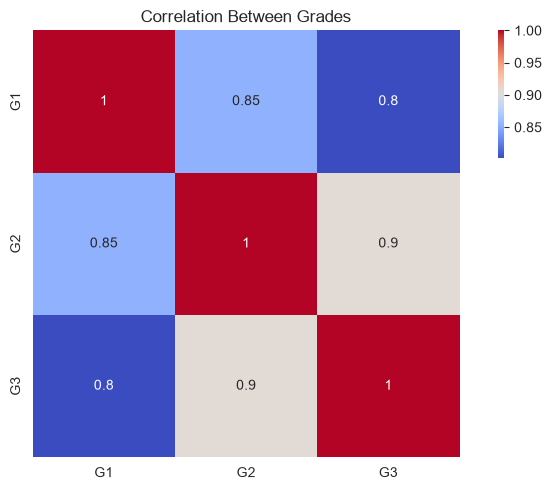

In [8]:
corr = data[['G1','G2','G3']].corr()
plt.figure(figsize=(8,5))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    square=True,
    cbar_kws={
        "shrink": 0.3,     
        "anchor": (0, 1.0) 
    }
)
plt.title("Correlation Between Grades")
plt.tight_layout()
plt.savefig("figures/Corr_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

Pairplot
    Here you obtain, 
    Histogram of each variable
    Scatterplots of every combination

<Figure size 600x400 with 0 Axes>

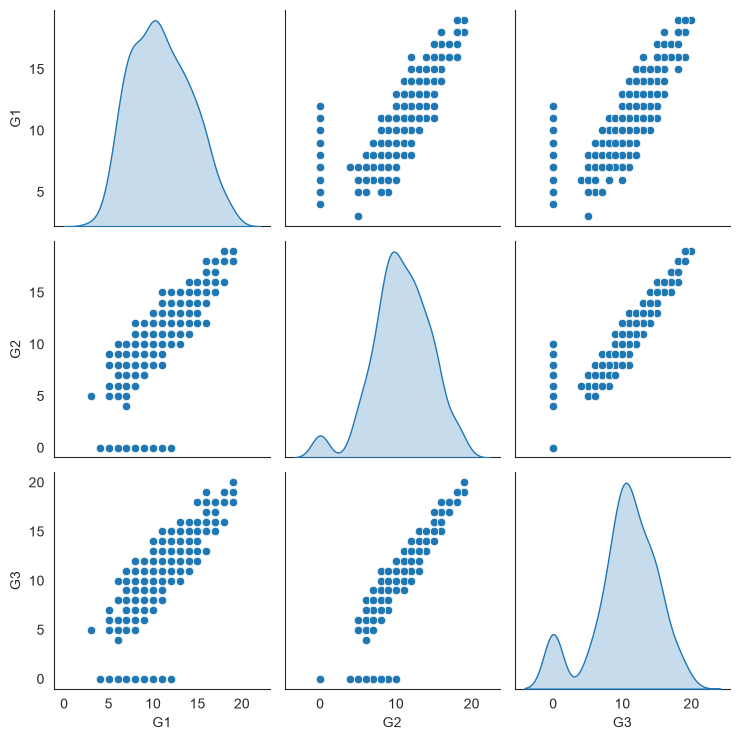

In [9]:
plt.figure(figsize=(6,4))
sns.set_style("white") # Remove gridlines
sns.pairplot(data[['G1','G2','G3']], diag_kind="kde")
plt.tight_layout()
plt.savefig("figures/pairplots.png", dpi=300)
plt.show()

Scatterplot
Below are scatter plots done seperately for grade verses each other 

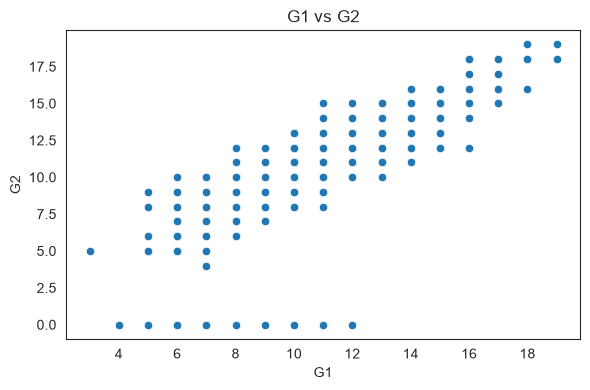

In [10]:
# G1 vs G2
plt.figure(figsize=(6,4))
sns.set_style("white") # Remove gridlines
sns.scatterplot(data=data, x="G1", y="G2")
plt.title("G1 vs G2")
plt.tight_layout()
plt.savefig("figures/scatter_plotA.png", dpi=300)
plt.show()

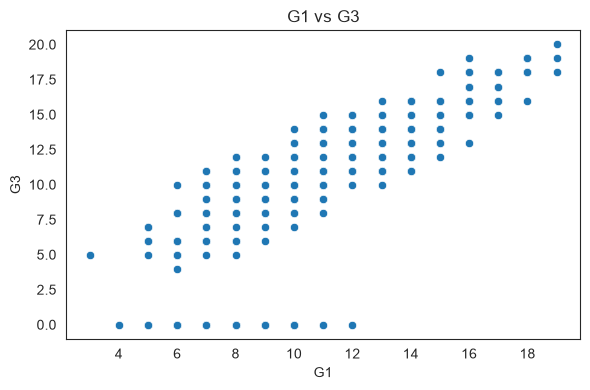

In [11]:
# G1 vs G3
plt.figure(figsize=(6,4))
sns.set_style("white") # Remove gridlines
sns.scatterplot(data=data, x="G1", y="G3")
plt.title("G1 vs G3")
plt.tight_layout()
plt.savefig("figures/scatter_plotB.png", dpi=300)
plt.show()

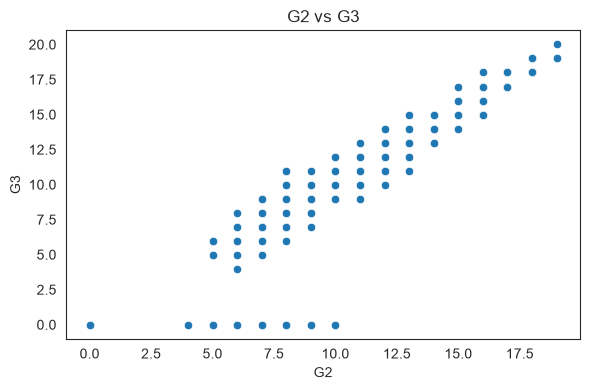

In [12]:
# G2 vs G3
plt.figure(figsize=(6,4))
sns.set_style("white") # Remove gridlines
sns.scatterplot(data=data, x="G2", y="G3")
plt.title("G2 vs G3")
plt.tight_layout()
plt.savefig("figures/scatter_plotC.png", dpi=300)
plt.show()

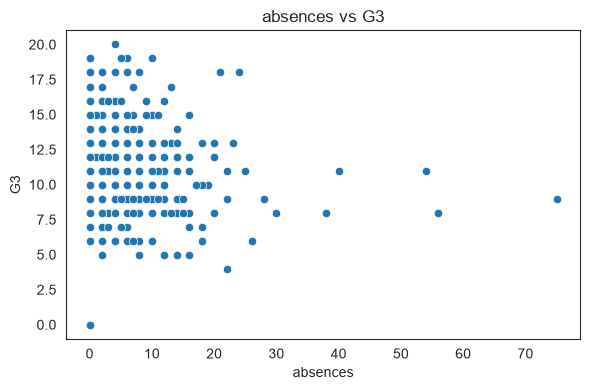

In [13]:
# absences vs G3
plt.figure(figsize=(6,4))
sns.set_style("white") # Remove gridlines
sns.scatterplot(data=data, x="absences", y="G3")
plt.title("absences vs G3")
plt.tight_layout()
plt.savefig("figures/scatter_plotD.png", dpi=300)
plt.show()

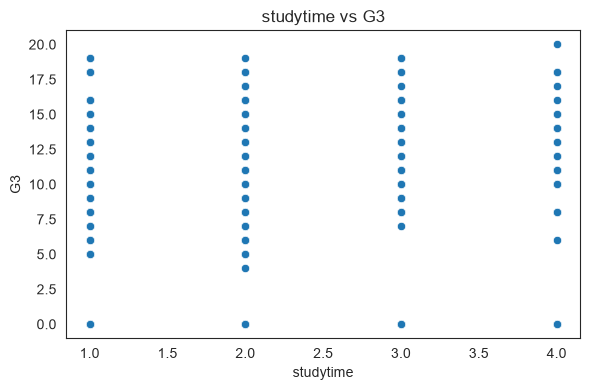

In [14]:
# studytime vs G3
plt.figure(figsize=(6,4))
sns.set_style("white") # Remove gridlines
sns.scatterplot(data=data, x="studytime", y="G3")
plt.title("studytime vs G3")
plt.tight_layout()
plt.savefig("figures/scatter_plotE.png", dpi=300)
plt.show()

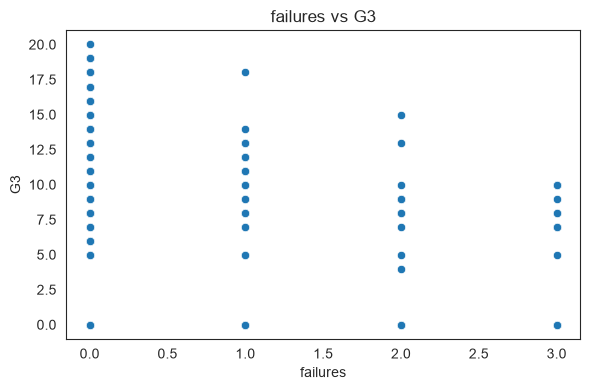

In [15]:
# failures vs G3
plt.figure(figsize=(6,4))
sns.set_style("white") # Remove gridlines
sns.scatterplot(data=data, x="failures", y="G3")
plt.title("failures vs G3")
plt.tight_layout()
plt.savefig("figures/scatter_plotF.png", dpi=300)
plt.show()

Compare Grade Progression
    To see whether
    students improve
    decline
    remain stable

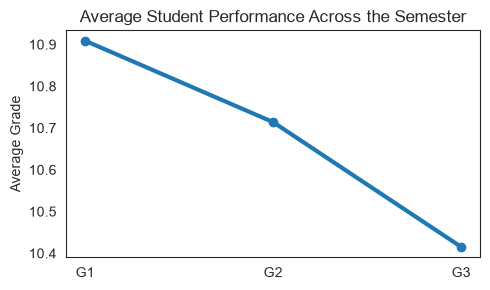

In [16]:
#The scale here is little bit zoomed in...to see a small difference
grade_mean = data[['G1','G2','G3']].mean()
plt.figure(figsize=(5,3))
plt.plot(grade_mean.index, grade_mean.values, marker='o', linewidth=3)
plt.ylabel("Average Grade")
plt.title("Average Student Performance Across the Semester")
plt.tight_layout()
plt.savefig("figures/mean_scorePlot1.png", dpi=300)
plt.show()

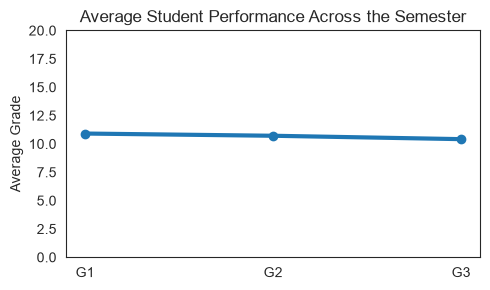

In [17]:
# Here the mean grade remain as it were, that way the 
# small difference in means between grade is not that prominent
grade_mean = data[['G1','G2','G3']].mean()
plt.figure(figsize=(5,3))
plt.plot(grade_mean.index, grade_mean.values, marker='o', linewidth=3)
plt.ylim(0,20)          # Full grade scale
plt.ylabel("Average Grade")
plt.title("Average Student Performance Across the Semester")
plt.tight_layout()
plt.savefig("figures/mean_scorePlot2.png", dpi=300)
plt.show()

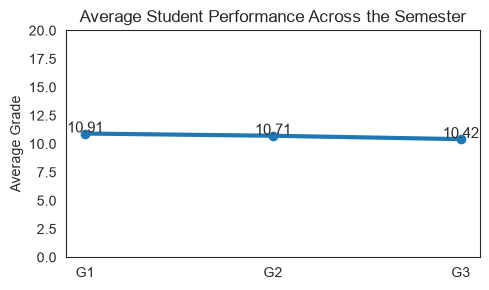

In [18]:
grade_mean = data[['G1','G2','G3']].mean()
plt.figure(figsize=(5,3))
plt.plot(grade_mean.index, grade_mean.values, marker='o', linewidth=3)

for x, y in zip(grade_mean.index, grade_mean.values):
    plt.text(x, y+0.1, f"{y:.2f}", ha='center', fontsize=11)
plt.ylim(0,20)
plt.ylabel("Average Grade")
plt.title("Average Student Performance Across the Semester")
plt.tight_layout()
plt.savefig("figures/mean_scorePlot3.png", dpi=300)
plt.show()

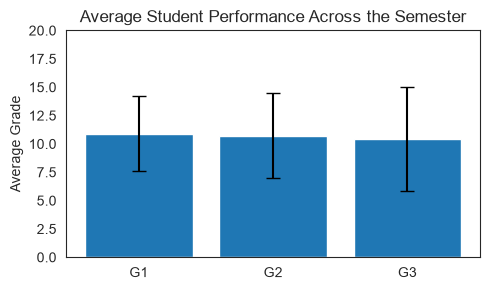

In [19]:
grade_mean = data[['G1','G2','G3']].mean()
grade_std  = data[['G1','G2','G3']].std()
plt.figure(figsize=(5,3))
plt.bar(grade_mean.index, grade_mean.values, yerr=grade_std, capsize=5)
plt.ylim(0,20)
plt.ylabel("Average Grade")
plt.title("Average Student Performance Across the Semester")
plt.tight_layout()
plt.savefig("figures/mean_scoreHisto.png", dpi=300)
plt.show()

You can also combine boxplot, violin and stripplot which plot the data points.
    Shows density
    Shows quartiles
    Shows every student
    Easy to interpret

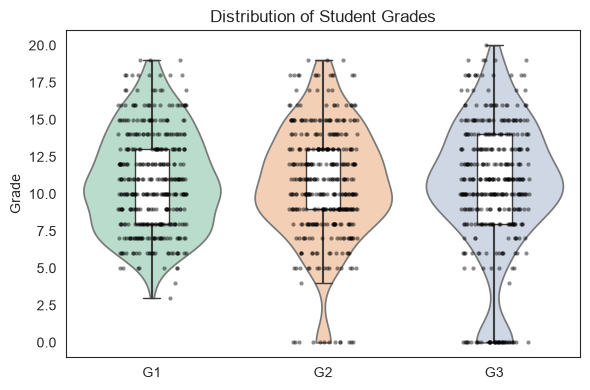

In [20]:
plt.figure(figsize=(6,4))
# Violin plot
sns.set_style("white") # Remove gridlines
sns.violinplot(data=data[['G1','G2','G3']], inner=None, palette="Pastel2", cut=0)
# Boxplot
sns.set_style("white") # Remove gridlines
sns.boxplot(
    data=data[['G1','G2','G3']],
    width=0.20,
    showcaps=True,
    boxprops={'facecolor':'white', 'zorder':3},
    showfliers=False,
    whiskerprops={'linewidth':1.5},
    medianprops={'color':'red', 'linewidth':2}
)

# Individual observations
sns.set_style("white") # Remove gridlines
sns.stripplot(data=data[['G1','G2','G3']], color='black', alpha=0.45, jitter=0.20, size=3)
plt.title("Distribution of Student Grades")
plt.ylabel("Grade")
plt.xlabel("")
plt.tight_layout()
plt.savefig("figures/box_violin_stripplot1.png", dpi=300)
plt.show()

Boxplot + stripplot (Data Points)

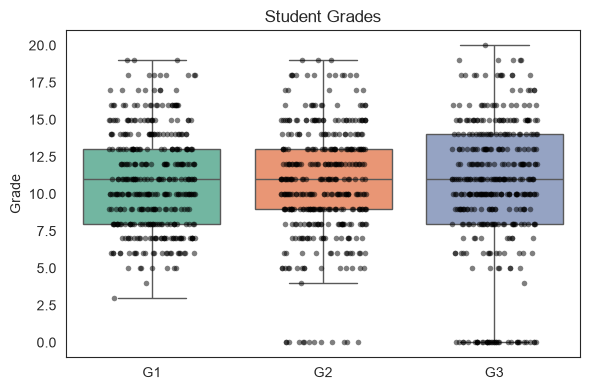

In [21]:
plt.figure(figsize=(6,4))
sns.set_style("white") # Remove gridlines
sns.boxplot(data=data[['G1','G2','G3']], palette="Set2", showfliers=False)
sns.set_style("white") # Remove gridlines
sns.stripplot(data=data[['G1','G2','G3']], color='black', alpha=0.5, jitter=0.25, size=4)
plt.title("Student Grades")
plt.ylabel("Grade")
plt.xlabel("")
plt.tight_layout()

plt.savefig("figures/box_stripplot1.png", dpi=300)
plt.show()

Boxplot + Swarmplot
    Instead of randomly jittering the points, swarmplot() arranges them so they don't overlap.

/Users/neuerbenutzer/.conda/envs/ml/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 5.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


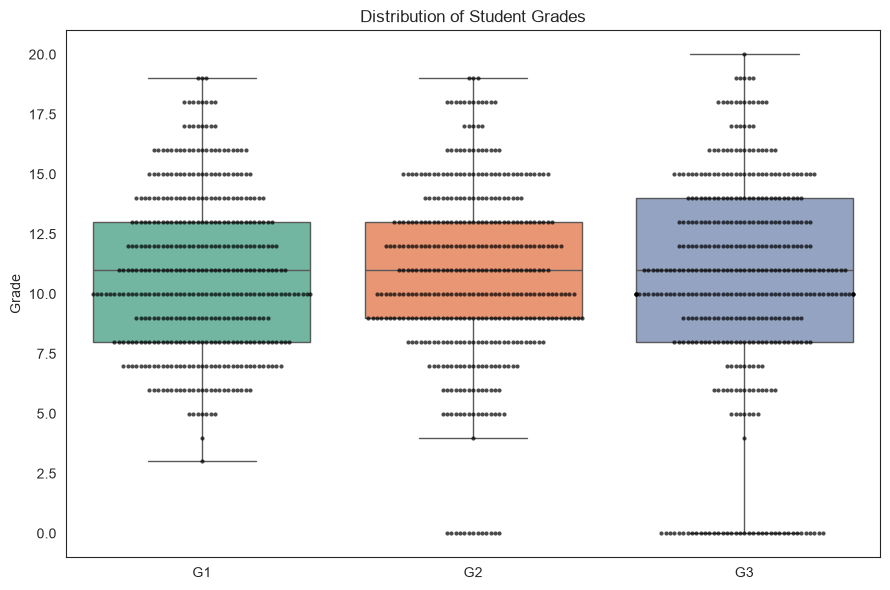

In [22]:
plt.figure(figsize=(9,6))
sns.set_style("white") # Remove gridlines
sns.boxplot(data=data[['G1','G2','G3']], palette="Set2", showfliers=False)
sns.set_style("white") # Remove gridlines
sns.swarmplot(data=data[['G1','G2','G3']], color="black", size=3, alpha=0.7)
plt.title("Distribution of Student Grades")
plt.ylabel("Grade")
plt.xlabel("")
plt.tight_layout()

plt.savefig("figures/box_swarmplot1.png", dpi=300)
plt.show()

Violin + Box + Swarm
This combines all the key information in a single visualization:
    Violin shows the full distribution shape.
    Boxplot highlights the median, quartiles, and spread.
    Swarmplot displays every student's grade without overlap.

/Users/neuerbenutzer/.conda/envs/ml/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 5.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


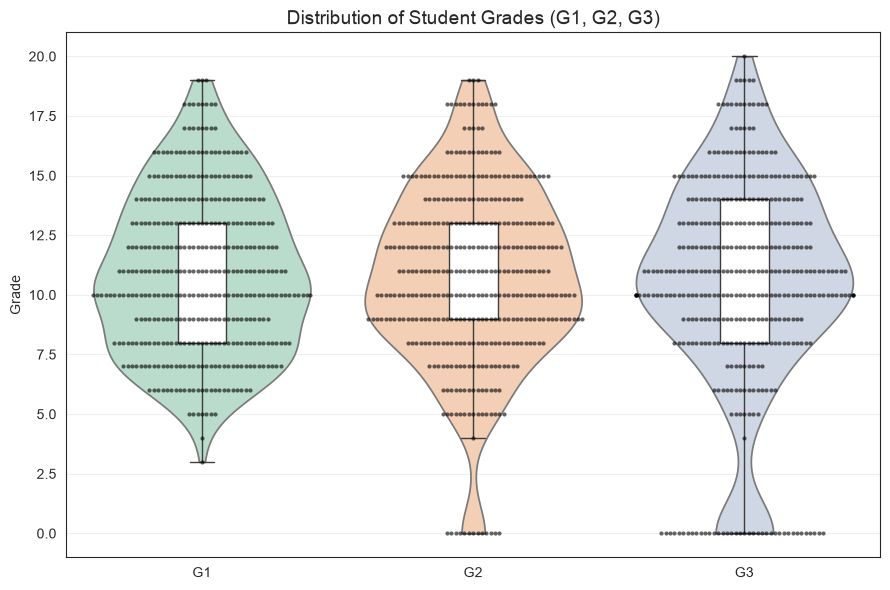

In [23]:
plt.figure(figsize=(9,6))

# Violin
sns.set_style("white") # Remove gridlines
sns.violinplot(
data=data[['G1','G2','G3']],
    inner=None,
    palette="Pastel2",
    cut=0
)

# Boxplot
sns.set_style("white") # Remove gridlines
sns.boxplot(
    data=data[['G1','G2','G3']],
    width=0.18,
    showfliers=False,
    boxprops={'facecolor':'white', 'zorder':3},
    medianprops={'color':'red', 'linewidth':2}
)

# Individual observations
sns.set_style("white") # Remove gridlines
sns.swarmplot(
    data=data[['G1','G2','G3']],
    color='black',
    size=3,
    alpha=0.6
)
sns.set_style("white") # Remove gridlines
plt.title("Distribution of Student Grades (G1, G2, G3)", fontsize=14)
plt.xlabel("")
plt.ylabel("Grade")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

plt.savefig("figures/box_violin_swarmplot1.png", dpi=300)
plt.show()

## MACHINE LEARNING (ML) 
Modelling 

### Trimming Our Data

Since we have so many attributes and not all are relevant we need to select the ones we want to use. We can do this by typing the following.

In [24]:
predict = "G3"
data = data[["G1", "G2", "studytime", "failures", "absences", "G3"]]

### Random seed for shuffling reproducibility 

for shuffling, it is better to do a random seed, so that every time we shuffle, we get the same result. without it i.e. (data = shuffle(data)) every run gives different results.

In [25]:
data = shuffle(data, random_state=42)

Now our data frame only has the information associated with those 6 attributes.

### Separating Our Data

Now that we've trimmed our data set down, we need to separate it into 4 arrays. However, before we can do that we need to define what attribute we are trying to predict. This attribute is known as a label. The other attributes that will determine our label are known as features. Once we've done this we will use numpy to create two arrays. One that contains all of our features and one that contains our labels.

In [26]:
predict = "G3"

X = data.drop(columns=[predict])
y = data[predict]


In [27]:
print(type(X))

<class 'pandas.DataFrame'>


### Data splitting for testing and training

After this we need to split our data into testing and training data. We will use 80% of our data to train and the other 20% to test. The reason we do this is so that we do not test our model on data that it has already seen.

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)           

## Linear Regression

How Does it Work?
Linear Regression is essentially just a best fit line. Given a set of data the algorithm will create a best fit line through those data points.
This line can be defined by the equation

$$y = m\cdot x + b.$$

$m$ is the slope. Meaning how much the $y$ value increases for each $x$ value.
$b$ is the $y$ intercept. Where the line crosses the $y$ axis.
We can determine the slope $(m)$ of the line by picking two points on the line ($p1$ and $p2$) and using the following equation: $$m = (y2 - y1) / (x2 - x1)$$ linear regression python
Once the computer has generated this line it will use it to predict certain values.

We will start by defining the model which we will be using.

In [29]:
# Create the model
linear = LinearRegression()

Next we will train and score our model using the arrays we created above.
To see how well our algorithm performed on our test data we can print out the score.
For this specific data set a score of above 80% is fairly good.


In [30]:
# Train the model
linear.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](5,)","[ 0.15, 0.98,-0.3 ,-0.35, 0.05]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](5,)","['G1','G2','studytime','failures','absences']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1.283
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(5)


If we want to see the constants used to generate the line we can type the following.

In [31]:
print('Coefficient: \n', linear.coef_) # These are each slope value
print('Intercept: \n', linear.intercept_) # This is the intercept

Coefficient: 
 [ 0.14844932  0.97959915 -0.29540951 -0.34513912  0.04779322]
Intercept: 
 -1.2834582495360838


In [32]:
linear.fit(X_train, y_train)
score = linear.score(X_test, y_test) #calculate our model score 
print(score)

0.8308371990858655


### Training Multiple Models

You may have noticed that our models vary in accuracy. This is because when we split the data into training and testing data, it is divided differently each time. Since our model trains very quickly it may be worth training multiple models and saving the best one. We can do this in the following way

 **k-fold cross-validation**, fits and scores the model on
several different folds and reports the honest mean and standard deviation,
then fits a single final model on the training split for the rest of the
notebook.

In [33]:
from sklearn.model_selection import cross_val_score, KFold
cv = KFold(n_splits=10, shuffle=True, random_state=42)
cv_scores = cross_val_score(LinearRegression(), X_train, y_train, cv=cv, scoring="r2")
print("10-fold CV R\u00b2 scores:", np.round(cv_scores, 3))
print(f"Mean R\u00b2: {cv_scores.mean():.3f}  (+/- {cv_scores.std():.3f} std)")

# Fit the final model once on the training split defined earlier. The seed
# is fixed only for reproducibility of THIS notebook run, not to cherry-pick
# whichever split happens to score best
linear = LinearRegression()
linear.fit(X_train, y_train)
score = linear.score(X_test, y_test)
print(f"\nHold-out test R\u00b2 (single split, used for the plots below): {score:.3f}")

with open("studentgrades.pickle", "wb") as f:
    pickle.dump(linear, f)

10-fold CV R² scores: [0.805 0.711 0.865 0.865 0.781 0.828 0.858 0.794 0.851 0.79 ]
Mean R²: 0.815  (+/- 0.046 std)

Hold-out test R² (single split, used for the plots below): 0.831


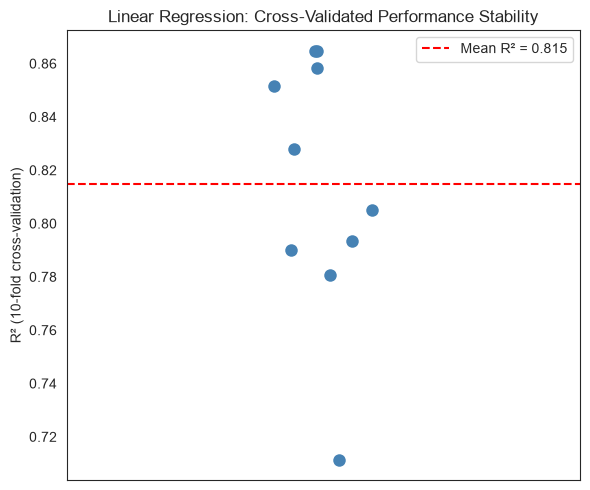

In [34]:
plt.figure(figsize=(6,5))
sns.stripplot(y=cv_scores, size=9, color="steelblue")
plt.axhline(cv_scores.mean(), color="red", linestyle="--",
            label=f"Mean R\u00b2 = {cv_scores.mean():.3f}")
plt.ylabel("R\u00b2 (10-fold cross-validation)")
plt.title("Linear Regression: Cross-Validated Performance Stability")
plt.legend()
plt.tight_layout()
plt.savefig("figures/linear_regression_cv_scores.png", dpi=300, bbox_inches="tight")
plt.show()

Loading the model

In [35]:
with open("studentgrades.pickle", "rb") as f:
    linear = pickle.load(f)

Predicting on Specific Students
Seeing a score value is cool but it is good to see how well the algorithm works on specific students. To do this we can print out all of our test data. Beside this data we can print the actual final grade and our models predicted grade.

In [36]:
linear_pred = linear.predict(X_test)

for i in range(len(linear_pred)):
    print(f"\nStudent {i+1}")
    print("Prediction:", round(linear_pred[i],2))
    print("Actual:", y_test.iloc[i])
    print(X_test.iloc[i])


Student 1
Prediction: 3.94
Actual: 5
G1            6
G2            5
studytime     1
failures      3
absences     16
Name: 18, dtype: int64

Student 2
Prediction: 12.01
Actual: 9
G1           10
G2            9
studytime     2
failures      0
absences     75
Name: 276, dtype: int64

Student 3
Prediction: 9.73
Actual: 9
G1           10
G2           10
studytime     2
failures      1
absences     14
Name: 44, dtype: int64

Student 4
Prediction: 13.21
Actual: 12
G1           10
G2           13
studytime     1
failures      0
absences     12
Name: 132, dtype: int64

Student 5
Prediction: 8.82
Actual: 10
G1           10
G2           10
studytime     4
failures      0
absences      0
Name: 71, dtype: int64

Student 6
Prediction: 9.1
Actual: 11
G1           10
G2           10
studytime     4
failures      0
absences      6
Name: 204, dtype: int64

Student 7
Prediction: 13.81
Actual: 14
G1           14
G2           14
studytime     3
failures      0
absences      4
Name: 329, dtype: int64

St

### Plotting Our Data / Model

To get a visual representation of our data we can plot it using the matplotlib library installed earlier.

We can use scatter plot to visualize our data.

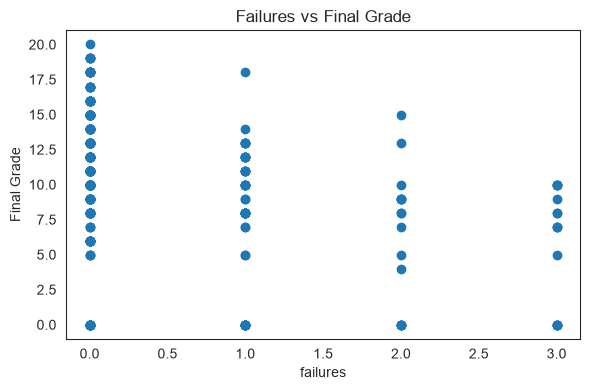

In [37]:
plot = "failures" # Change this to G1, G2, studytime or absences to see other graphs
plt.figure(figsize=(6,4))
plt.scatter(data[plot], data["G3"])
plt.xlabel(plot)
plt.ylabel("Final Grade")
plt.title("Failures vs Final Grade")
plt.tight_layout()

plt.savefig("figures/model_scatter1.png", dpi=300)
plt.show()

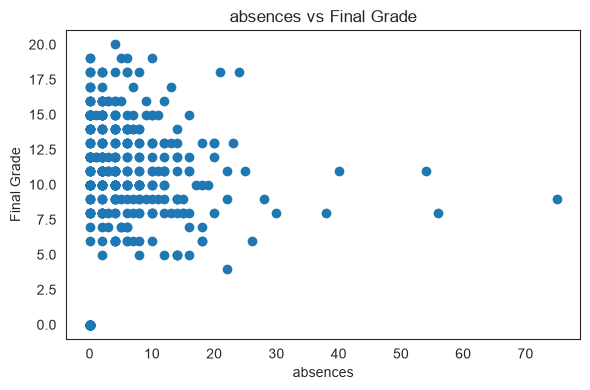

In [38]:
plot = "absences" 
plt.figure(figsize=(6,4))
plt.scatter(data[plot], data["G3"])
plt.xlabel(plot)
plt.ylabel("Final Grade")
plt.title("absences vs Final Grade")
plt.tight_layout()

plt.savefig("figures/model_scatter2.png", dpi=300)

plt.show()

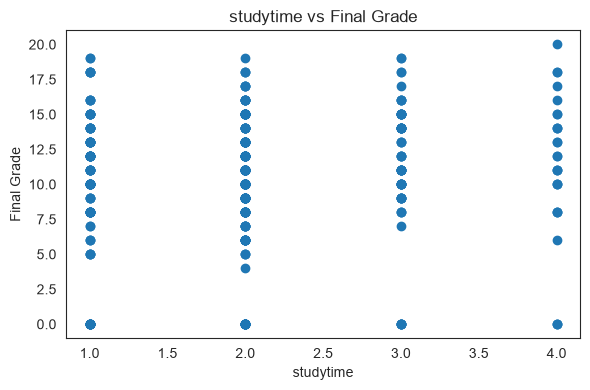

In [39]:
plot = "studytime" 
plt.figure(figsize=(6,4))
plt.scatter(data[plot], data["G3"])
plt.xlabel(plot)
plt.ylabel("Final Grade")
plt.title("studytime vs Final Grade")
plt.tight_layout()

plt.savefig("figures/model_scatter3.png", dpi=300)
plt.show()

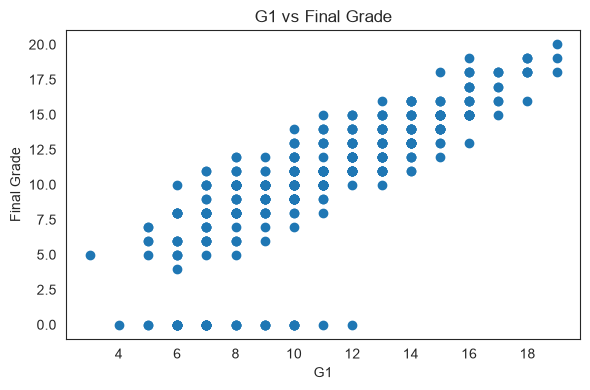

In [40]:
plot = "G1"
plt.figure(figsize=(6,4))
plt.scatter(data[plot], data["G3"])
plt.xlabel(plot)
plt.ylabel("Final Grade")
plt.title("G1 vs Final Grade")
plt.tight_layout()

plt.savefig("figures/model_scatter4.png", dpi=300)
plt.show()

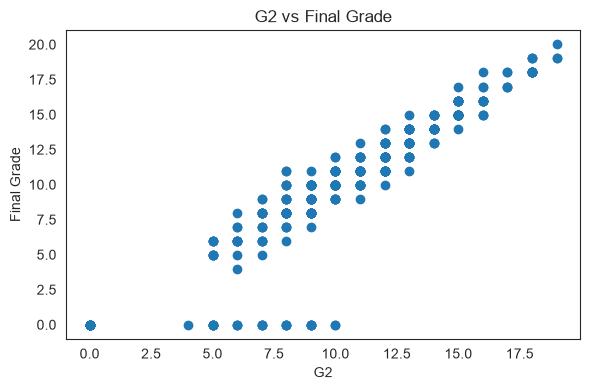

In [41]:
plot = "G2" 
plt.figure(figsize=(6,4))
plt.scatter(data[plot], data["G3"])
plt.xlabel(plot)
plt.ylabel("Final Grade")
plt.title("G2 vs Final Grade")
plt.tight_layout()

plt.savefig("figures/model_scatter5.png", dpi=300)
plt.show()

## Decision Tree Regression

Import the module 

In [42]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import (r2_score, mean_absolute_error, mean_squared_error)

### Train the model

In [43]:
tree = DecisionTreeRegressor(random_state=42)
tree.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes 

### Predict 

In [44]:
tree_pred = tree.predict(X_test)

### Evaluate the model

In [45]:
print("Decision Tree Results")
print("----------------------")

print("R² :", r2_score(y_test, tree_pred))
print("MAE:", mean_absolute_error(y_test, tree_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, tree_pred)))

Decision Tree Results
----------------------
R² : 0.5497519648301131
MAE: 1.409282700421941
RMSE: 2.5110165149029444


## Random Forest Regression

### Import the module

In [46]:
from sklearn.ensemble import RandomForestRegressor

### Train the model

In [47]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

### Predict

In [48]:
rf_pred = rf.predict(X_test)

### Evaluate 

In [49]:
print("Random Forest Results")
print("----------------------")

print("R² :", r2_score(y_test, rf_pred))
print("MAE:", mean_absolute_error(y_test, rf_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))

Random Forest Results
----------------------
R² : 0.855427512416026
MAE: 0.9767272453285112
RMSE: 1.4228741283433408


### Features importance 

In [50]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})
importance = importance.sort_values( by="Importance", ascending=False)
importance.head(10)

,Feature,Importance
1,G2,0.788682
4,absences,0.140440
0,G1,0.026669
2,studytime,0.026278
3,failures,0.017932


### Plot the features 

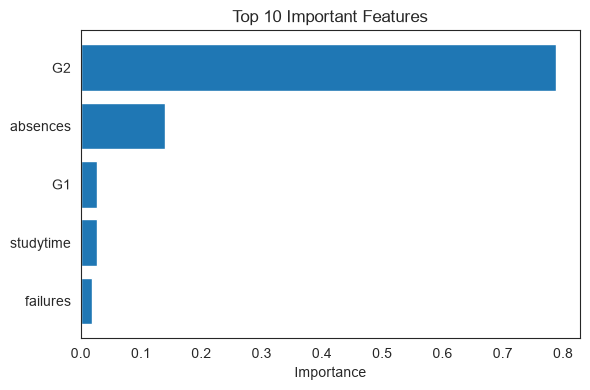

In [51]:
plt.figure(figsize=(6,4))
plt.barh(importance["Feature"][:10], importance["Importance"][:10])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("Top 10 Important Features")
plt.tight_layout()
plt.savefig("figures/Top 10 Important Features.png", dpi=300, bbox_inches="tight")
plt.show()

## XGBoost Regression

### Install the package xgboost

In [52]:
try:
    from xgboost import XGBRegressor
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False
    print("[warning] xgboost is not installed - the XGBoost model will be "
          "skipped in the comparisons below. Install with `pip install xgboost` "
          "and re-run to include it.")

### Train the model

In [53]:
if XGBOOST_AVAILABLE:
    xgb = XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        random_state=42
    )
    xgb.fit(X_train, y_train)

### Predict

In [54]:
xgb_pred = xgb.predict(X_test) if XGBOOST_AVAILABLE else None

### Evaluate

In [55]:
if XGBOOST_AVAILABLE:
    print("XGBoost Results")
    print("----------------")
    print("R² :", r2_score(y_test, xgb_pred))
    print("MAE:", mean_absolute_error(y_test, xgb_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_test, xgb_pred)))
else:
    print("[skipped] XGBoost is not installed in this environment.")

XGBoost Results
----------------
R² : 0.836060106754303
MAE: 1.0023858547210693
RMSE: 1.5151858922641983


### Compare the model 

But before that we can print our models to see whether we are using same amount data for training and testing 

In [56]:
print("X_test shape:", X_test.shape)
print("y_test length:", len(y_test))
print("linear_pred length:", len(linear_pred))
print("tree_pred length:", len(tree_pred))
print("rf_pred length:", len(rf_pred))
print("xgb_pred length:", len(xgb_pred) if XGBOOST_AVAILABLE else "n/a (xgboost not installed)")

X_test shape: (79, 5)
y_test length: 79
linear_pred length: 79
tree_pred length: 79
rf_pred length: 79
xgb_pred length: 79


### Compare all the models 

In [57]:
all_preds = {
    "Linear Regression": linear_pred,
    "Decision Tree": tree_pred,
    "Random Forest": rf_pred,
}
if XGBOOST_AVAILABLE:
    all_preds["XGBoost"] = xgb_pred

results = pd.DataFrame({
    "Model": list(all_preds.keys()),
    "R²": [r2_score(y_test, p) for p in all_preds.values()],
    "MAE": [mean_absolute_error(y_test, p) for p in all_preds.values()],
    "RMSE": [np.sqrt(mean_squared_error(y_test, p)) for p in all_preds.values()],
})

results.sort_values("R²", ascending=False)

,Model,R²,MAE,RMSE
2,Random Forest,0.855428,0.976727,1.422874
3,XGBoost,0.836060,1.002386,1.515186
0,Linear Regression,0.830837,1.092657,1.539133
1,Decision Tree,0.549752,1.409283,2.511017


We can use residual plots to evaluate the prediction errors of the four regression models. A residual is the difference between the actual and predicted final grade:

$Residual = Actual G3 − Predicted G3$

The residuals are plotted against the predicted values for each model using different colours and marker shapes. A horizontal reference line at $0$ represents perfect predictions. Ideally, residuals should be randomly scattered around this line with no obvious pattern and a small spread. Such a distribution indicates that the model produces unbiased predictions and fits the data well. Comparing the residual distributions across models helps identify which model provides the most accurate and consistent predictions.

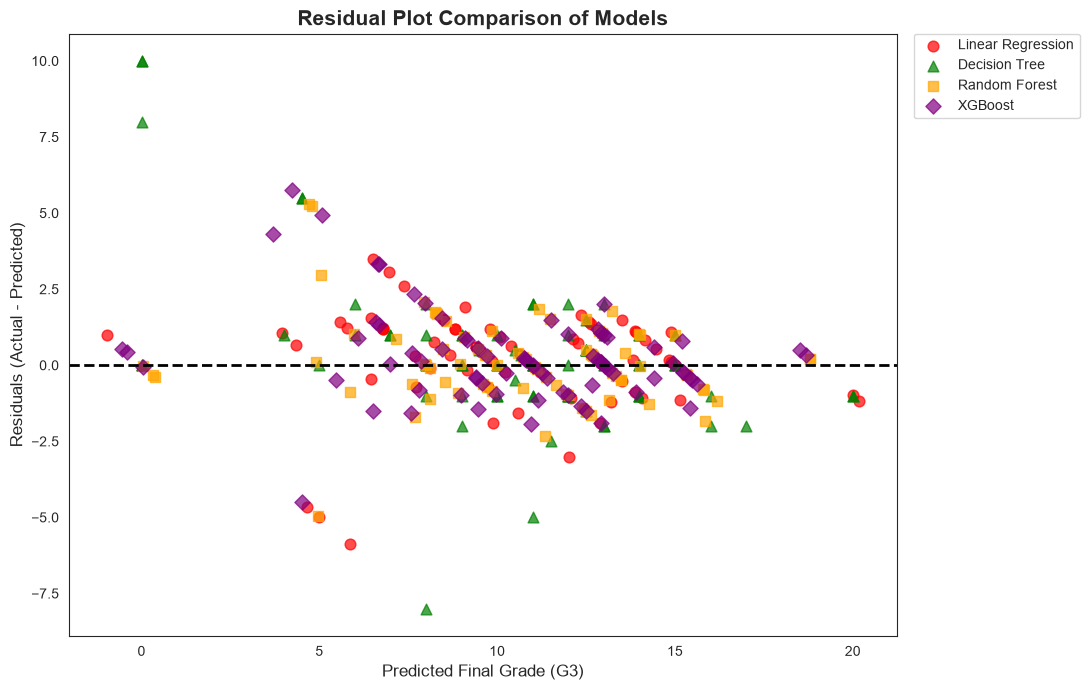

In [58]:
# Calculate residuals for every available model 
residual_style = {
    "Linear Regression": dict(color="red", marker="o"),
    "Decision Tree": dict(color="green", marker="^"),
    "Random Forest": dict(color="orange", marker="s"),
    "XGBoost": dict(color="purple", marker="D"),
}

plt.figure(figsize=(11,7))
for name, pred in all_preds.items():
    residuals = y_test - pred
    style = residual_style[name]
    plt.scatter(
        pred, residuals, s=60, alpha=0.7, label=name,
        color=style["color"], marker=style["marker"]
    )

# Zero residual reference line
plt.axhline(
    y=0,
    color="black",
    linestyle="--",
    linewidth=2
)

plt.xlabel("Predicted Final Grade (G3)", fontsize=12)
plt.ylabel("Residuals (Actual - Predicted)", fontsize=12)
plt.title("Residual Plot Comparison of Models", fontsize=15, fontweight="bold")

plt.legend(
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    borderaxespad=0
)
plt.grid(False)
plt.tight_layout()

plt.savefig("figures/Residual Plot Comparison of Models.png", dpi=300, bbox_inches="tight")
plt.show()

We can create one figure for each predictor, and overlay the model predictions.
Here we can show on one plot
    Actual values (blue dots)
    Linear Regression prediction (red line)
    Decision Tree prediction (green dots)
    Random Forest prediction (orange dots)
    XGBoost prediction (purple dots)

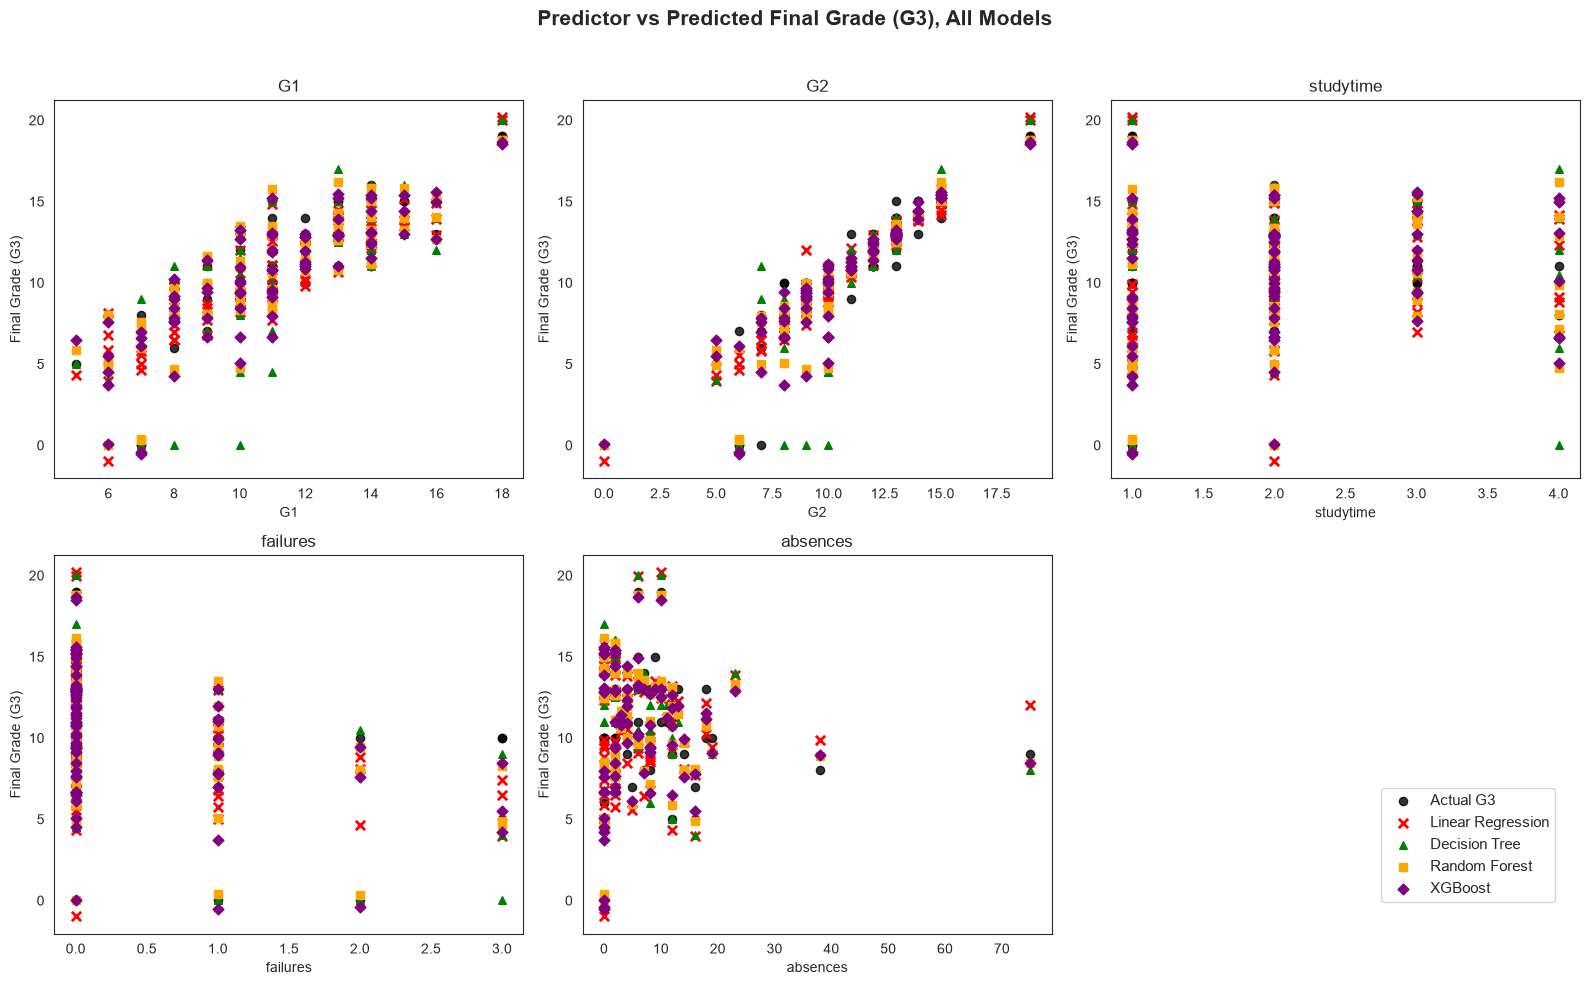

In [59]:
# Predictor variables used in the models
features = ["G1", "G2", "studytime", "failures", "absences"]
pred_style = {
    "Decision Tree": dict(color="green", marker="^"),
    "Random Forest": dict(color="orange", marker="s"),
    "XGBoost": dict(color="purple", marker="D"),
}

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for ax, feature in zip(axes, features):
    sorted_idx = np.argsort(X_test[feature])
    x = X_test[feature].iloc[sorted_idx]
    actual = y_test.iloc[sorted_idx]

    ax.scatter(x, actual, color="black", alpha=0.8, s=35, label="Actual G3")
    ax.scatter(x, linear_pred[sorted_idx], color="red", marker="x", s=45,
               linewidth=2, label="Linear Regression")
    for name in ("Decision Tree", "Random Forest", "XGBoost"):
        if name not in all_preds:
            continue
        style = pred_style[name]
        ax.scatter(x, all_preds[name][sorted_idx], s=30, label=name, **style)

    ax.set_xlabel(feature)
    ax.set_ylabel("Final Grade (G3)")
    ax.set_title(feature)
    ax.grid(False)

# One shared legend instead of repeating it 5 times; drop the unused 6th axis
handles, labels = axes[0].get_legend_handles_labels()
fig.delaxes(axes[5])
fig.legend(handles, labels, loc="lower right", bbox_to_anchor=(0.98, 0.08),
           fontsize=11, frameon=True)
fig.suptitle("Predictor vs Predicted Final Grade (G3), All Models", fontsize=15, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.savefig("figures/feature vs Predicted Final Grade.png", dpi=300, bbox_inches="tight")
plt.show()

## Plotting Actual vs Predicted for each model

Plotting only one predictor against G3 can sometimes give a misleading impression. For example, two students may have the same G2 score but different G1, studytime, or failures, leading to different predictions.
for accuracy of model preditcion and to make it more informative for comparison of the models applied the best way is to plot Actual vs Predicted for each model. This evaluates the overall model performance rather than isolating a single feature. See below. 
The closer the points are to the red 45° line, the more accurate the model. Points above the line indicate over-prediction, while points below indicate under-prediction.

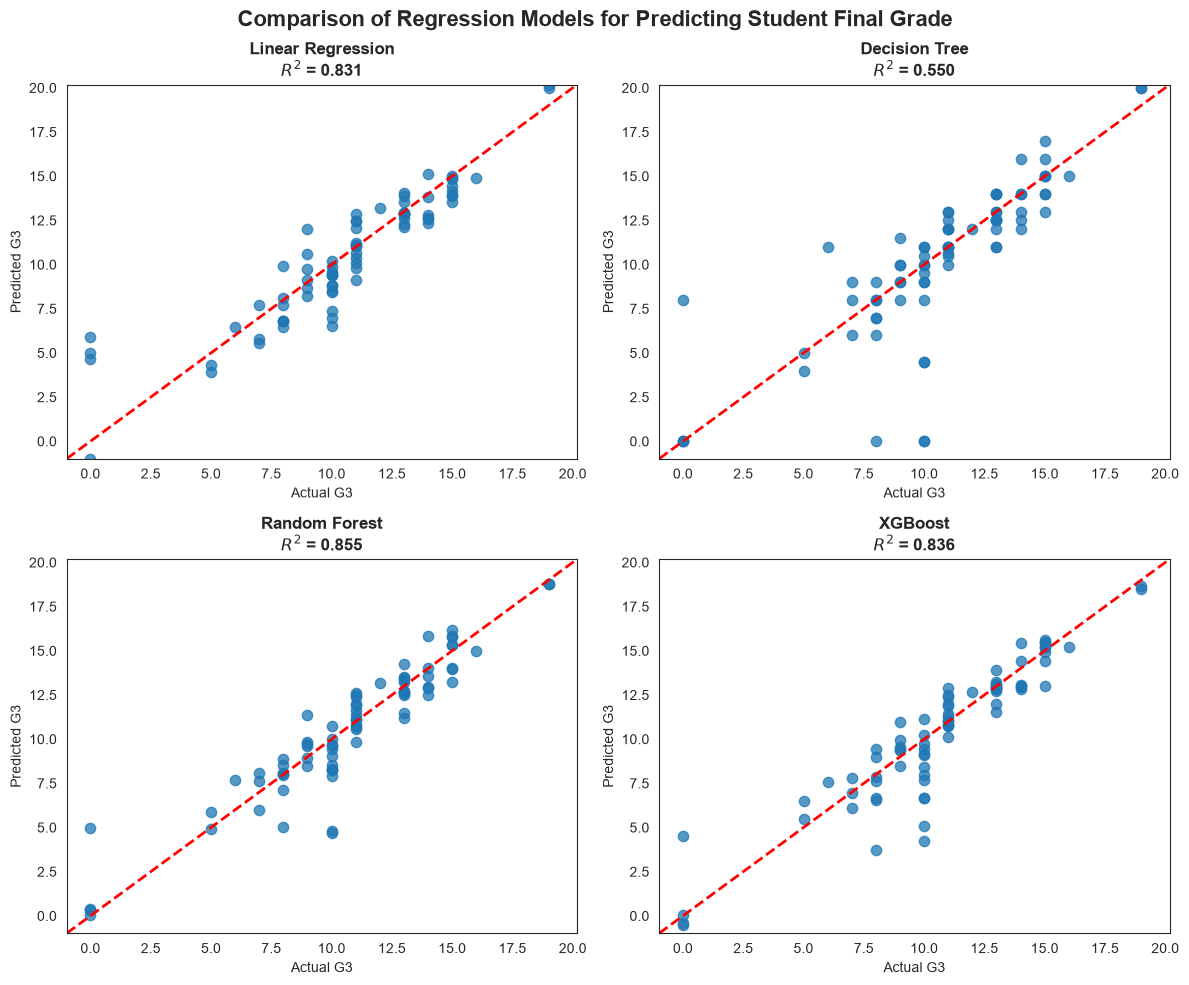

In [60]:
fig, axes = plt.subplots(2, 2, figsize=(12,10))
axes = axes.flatten()

min_val = min(y_test.min(), *(pred.min() for pred in all_preds.values()))
max_val = max(y_test.max(), *(pred.max() for pred in all_preds.values()))

for ax, (name, pred) in zip(axes, all_preds.items()):

    r2 = r2_score(y_test, pred)

    ax.scatter(y_test, pred, alpha=0.75, s=55)

    ax.plot(
        [min_val, max_val],
        [min_val, max_val],
        'r--',
        linewidth=2
    )

    ax.set_title(f"{name}\n$R^2$ = {r2:.3f}",
                 fontsize=12,
                 fontweight='bold')

    ax.set_xlabel("Actual G3")
    ax.set_ylabel("Predicted G3")

    ax.set_xlim(min_val, max_val)
    ax.set_ylim(min_val, max_val)

    ax.grid(False)

# Hide any unused subplot slots (e.g. if XGBoost is unavailable, only 3 models)
for ax in axes[len(all_preds):]:
    ax.set_visible(False)

plt.suptitle(
    "Comparison of Regression Models for Predicting Student Final Grade",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "figures/Comparison of Regression Models for Predicting Student Final Grade.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Checking for a hidden scientific flaw: are G1 and G2 *leaking* the answer?

G1, G2 and G3 are three periodic exam grades **from the same course**, so G2
is close to a preview of G3 rather than an independent predictor,  the
correlation heatmap earlier already showed a very strong G2–G3 relationship.
Including G1 and G2 as predictors makes the regression task close to
trivial and can hide how much (or how little) the genuinely *behavioural*
features;  study time, prior failures, and absences,  actually explain
about final performance on their own. A caveat of this 
dataset: We can do the analysis under three scenarios, using 10-fold cross-validated R² rather
than a single train/test split, to make the effect transparent.

,Scenario,Mean R2,Std R2
0,G1 + G2 + behavioural,0.845578,0.095034
1,G2 + behavioural only,0.849209,0.114189
2,Behavioural only\n(no prior grades),0.083504,0.199008


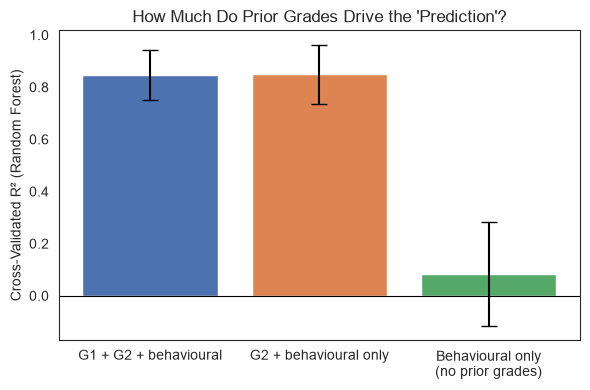

In [61]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, KFold

scenarios = {
    "G1 + G2 + behavioural": ["G1", "G2", "studytime", "failures", "absences"],
    "G2 + behavioural only": ["G2", "studytime", "failures", "absences"],
    "Behavioural only\n(no prior grades)": ["studytime", "failures", "absences"],
}

cv = KFold(n_splits=10, shuffle=True, random_state=42)
scenario_results = []
for label, feats in scenarios.items():
    scores = cross_val_score(
        RandomForestRegressor(n_estimators=200, random_state=42),
        data[feats], data["G3"],
        cv=cv, scoring="r2"
    )
    scenario_results.append({"Scenario": label, "Mean R2": scores.mean(), "Std R2": scores.std()})

scenario_df = pd.DataFrame(scenario_results)
display(scenario_df)

plt.figure(figsize=(6,4))
plt.bar(
    scenario_df["Scenario"], scenario_df["Mean R2"],
    yerr=scenario_df["Std R2"], capsize=6,
    color=["#4C72B0", "#DD8452", "#55A868"]
)
plt.ylabel("Cross-Validated R\u00b2 (Random Forest)")
plt.title("How Much Do Prior Grades Drive the \'Prediction\'?")
plt.axhline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.savefig("figures/grade_leakage_ablation.png", dpi=300, bbox_inches="tight")
plt.show()